In [ ]:
pip install -q langgraph langchain langchain-openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.9/154.9 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.4/63.4 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.3/438.3 kB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.5/216.5 kB 8.9 MB/s eta 0:00:00


In [ ]:
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages, AnyMessage
from typing import List, TypedDict, Annotated

In [ ]:
class GraphState(TypedDict):
  messages: list[AnyMessage]

In [ ]:
class GraphState(TypedDict):
  messages: Annotated[List[str], add_messages]

In [ ]:
from langgraph.graph import MessagesState

In [ ]:
def node_a(state: MessagesState) -> GraphState:
  return {"messages": ["Hello from A"]}

def node_b(state: MessagesState) -> GraphState:
  return {"messages": ["Hi from B"]}

def node_c(state: MessagesState) -> GraphState:
  return {"messages": ["Hi from C"]}

In [ ]:
builder = StateGraph(MessagesState)

builder.add_node("A", node_a)
builder.add_node("B", node_b)
builder.add_node("C", node_c)

#builder.add_edge(START,"A")
builder.set_entry_point("A")
builder.add_edge("A","B")
builder.add_edge("A","C")
#builder.add_edge("Final",END)
builder.set_finish_point("C")

graph = builder.compile()

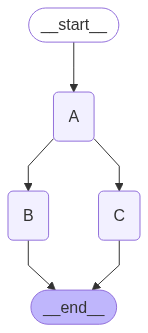

In [ ]:
from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
initial_state = {"messages":[]}

result = graph.invoke(initial_state)

In [ ]:
print(result['messages'])

[HumanMessage(content='Hello from A', additional_kwargs={}, response_metadata={}, id='2aa1923d-5304-44e4-bd65-1f84de3a4855'), HumanMessage(content='Hi from B', additional_kwargs={}, response_metadata={}, id='c97ad7ef-db74-4d51-af2f-3d5369c92bea'), HumanMessage(content='Hi from C', additional_kwargs={}, response_metadata={}, id='b3c79db7-f5d8-443b-931e-90add4722c85')]
